In [7]:
import numpy as np
import cv2 as cv
import glob
import os

# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

pattern_size = (5, 3)  # inner corners: columns, rows
objp = np.zeros((15, 3), np.float32)
objp[:, :2] = np.mgrid[0:5, 0:3].T.reshape(-1, 2)
objp[:, 0] *= 15.8
objp[:, 1] *= 9.6
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

video_path = 'lego_twogrids.mp4'
#'/content/drive/MyDrive/WhatsApp Video 2026-09-17 at 15.27.13.mp4'

# Create a directory to save processed frames for debugging
output_dir = 'processed_frames'
os.makedirs(output_dir, exist_ok=True)

cap = cv.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
else:
    frame_count = 0
    detected_frames_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break # Break the loop if no more frames

        frame_count += 1
        # Process every Nth frame to avoid processing too many identical frames
        # Reduced to every 10th frame for more frequent checks
        if frame_count % 10 == 0:
            print(f"Processing frame {frame_count}...")
            img_to_save = frame.copy() # Make a copy to draw on for visualization
            gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

            # Find the chess board corners
            # IMPORTANT: Using the user-specified (5,3) for inner corners.
            found, corners = cv.findChessboardCorners(gray, (5,3), None, cv.CALIB_CB_ADAPTIVE_THRESH + cv.CALIB_CB_NORMALIZE_IMAGE)

            # If found, add object points, image points (after refining them)
            if found == True:
                objpoints.append(objp)

                corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
                imgpoints.append(corners2)
                detected_frames_count += 1
                print(f"  Chessboard found in frame {frame_count}! Total detected: {detected_frames_count}")
                # Draw corners on the copy for saving
                cv.drawChessboardCorners(img_to_save, (5,3), corners2, found)
            else:
                print(f"  Chessboard NOT found in frame {frame_count}.")

            # Save the processed frame (with or without drawn corners) for inspection
            output_filename = os.path.join(output_dir, f"frame_{frame_count:04d}_{'detected' if found else 'not_detected'}.jpg")
            cv.imwrite(output_filename, img_to_save)

    cap.release()
    print(f"Finished processing. Total frames processed: {frame_count}. Chessboards detected: {detected_frames_count}")
    print(f"You can inspect saved frames in the directory: {output_dir}")

Processing frame 10...
  Chessboard found in frame 10! Total detected: 1
Processing frame 20...
  Chessboard found in frame 20! Total detected: 2
Processing frame 30...
  Chessboard found in frame 30! Total detected: 3
Processing frame 40...
  Chessboard found in frame 40! Total detected: 4
Processing frame 50...
  Chessboard found in frame 50! Total detected: 5
Processing frame 60...
  Chessboard found in frame 60! Total detected: 6
Processing frame 70...
  Chessboard found in frame 70! Total detected: 7
Processing frame 80...
  Chessboard found in frame 80! Total detected: 8
Processing frame 90...
  Chessboard found in frame 90! Total detected: 9
Processing frame 100...
  Chessboard found in frame 100! Total detected: 10
Processing frame 110...
  Chessboard found in frame 110! Total detected: 11
Processing frame 120...
  Chessboard found in frame 120! Total detected: 12
Processing frame 130...
  Chessboard found in frame 130! Total detected: 13
Processing frame 140...
  Chessboard fo

In [8]:
if len(imgpoints) < 3:
    raise ValueError("Too few detected views; use more varied board poses.")

rms, mtx, dist, rvecs, tvecs = cv.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None
)

per_view_rms = []
for obj, observed, rvec, tvec in zip(
    objpoints, imgpoints, rvecs, tvecs
):
    projected, _ = cv.projectPoints(obj, rvec, tvec, mtx, dist)

    observed = np.asarray(observed, dtype=np.float64).reshape(-1, 2)
    projected = np.asarray(projected, dtype=np.float64).reshape(-1, 2)

    residuals = observed - projected
    per_view_rms.append(
        np.sqrt(np.mean(np.sum(residuals**2, axis=1)))
    )

print("Camera matrix:\n", mtx)
print("Distortion coefficients:\n", dist)
print(f"Overall RMS reprojection error: {rms:.3f} pixels")
print("Per-view RMS errors:", np.round(per_view_rms, 3))

np.savez(
    "camera_calibration.npz",
    mtx=mtx,
    dist=dist,
    image_size=np.array(gray.shape[::-1]),
    rvecs=np.asarray(rvecs),
    tvecs=np.asarray(tvecs),
    per_view_rms=np.asarray(per_view_rms),
)

Camera matrix:
 [[1.10042862e+03 0.00000000e+00 6.26815168e+02]
 [0.00000000e+00 1.08153485e+03 3.35504278e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion coefficients:
 [[-0.06718938 -0.06392721 -0.00766693 -0.00337932  0.79210832]]
Overall RMS reprojection error: 0.141 pixels
Per-view RMS errors: [0.12  0.121 0.156 0.155 0.131 0.147 0.146 0.165 0.082 0.129 0.114 0.115
 0.166 0.132 0.139 0.156 0.148 0.125 0.157 0.143 0.081 0.084 0.123 0.134
 0.105 0.134 0.135 0.142 0.113 0.128 0.148 0.154 0.173 0.16  0.191 0.22
 0.162 0.153 0.138 0.115 0.102 0.13  0.125 0.137 0.097 0.105 0.27  0.126
 0.154 0.101 0.097 0.132 0.184 0.135 0.136 0.129 0.118]


Class results
K:
 [[369 0 173]
 [0 363 163]
 [0 0 1]]

R:
 [[0.99 0 0.01]
 [0 0.99 0.01]
 [0.1 0.1 0.99]]

T:
 [-0.1 0.03 0.7].T

In [9]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

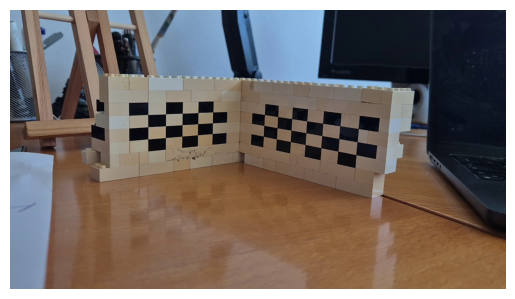

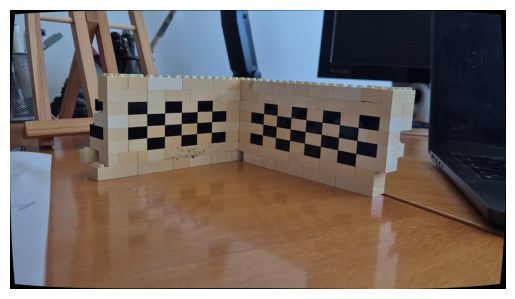

In [13]:
cap = cv.VideoCapture(video_path)
ok, img = cap.read()
cap.release()

if not ok or img is None:
    raise RuntimeError(f"Could not read a frame from {video_path}")

h, w = img.shape[:2]
newcameramtx, roi = cv.getOptimalNewCameraMatrix(
    mtx, dist, (w, h), 1, (w, h)
)

undistorted = cv.undistort(img, mtx, dist, None, newcameramtx)

# Display in Google Colab
#from google.colab.patches import cv2_imshow
#cv2_imshow(img)
#cv2_imshow(undistorted)

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(cv.cvtColor(undistorted, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Why do we need cv2.cvtColor()?

OpenCV reads images in BGR order:

OpenCV → Blue, Green, Red

Matplotlib expects:

Matplotlib → Red, Green, Blue

So:

cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

converts the image correctly before displaying it.

evaluate output with error !!!